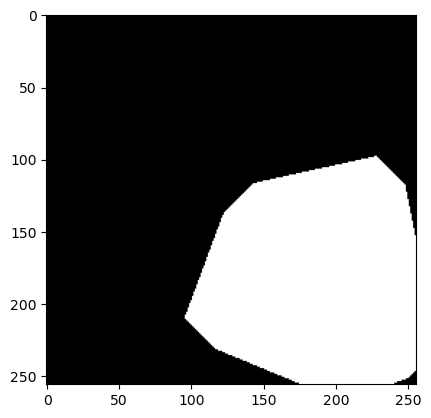

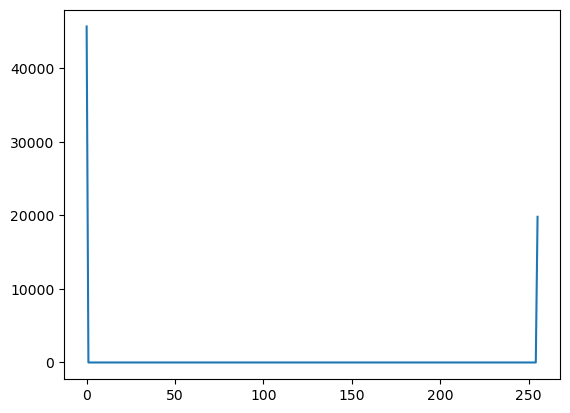

In [203]:
import cv2
import matplotlib.pyplot as plt

spot = cv2.imread('SPOT.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(spot, cmap='gray', vmin=0, vmax=255)
plt.show()
histS = cv2.calcHist([spot],[0],None,[256],[0,256])
plt.plot(histS)
plt.show()

spot = spot.astype('int16')

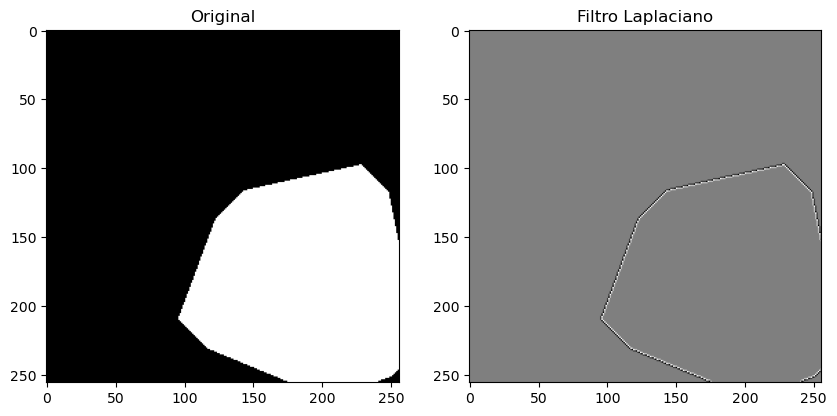

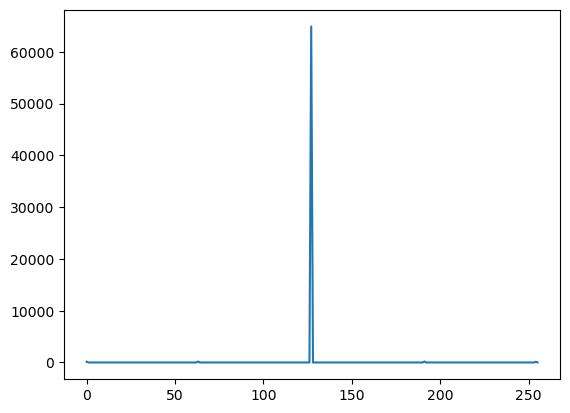

In [204]:
from skimage.filters import laplace
from skimage import exposure

laplacian = laplace(spot, ksize=3)
spotLaplacian = exposure.rescale_intensity(laplacian, in_range=(laplacian.min(), laplacian.max()), out_range=(0, 255))
spotLaplacian = spotLaplacian.astype('uint8')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(spot, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,2,2)
plt.imshow(spotLaplacian, cmap='gray', vmin=0, vmax=255)
plt.title("Filtro Laplaciano")
plt.show()

hist = cv2.calcHist([spotLaplacian],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()


### ¿Cómo es la respuesta del Laplaciano en las regiones homogéneas de la imagen y en los contornos? ¿A qué se debe este resultado?

En las regiones homogéneas de la imagen, el filtro Laplaciano tiene valores cercanos a cero porque la intensidad de los píxeles varía muy poco, lo que implica que la segunda derivada es baja o nula. En los contornos, el Laplaciano genera valores altos (positivos y negativos) debido a los cambios bruscos de intensidad, lo que indica la presencia de bordes (representados por la leve cantidad de pixeles blancos y negros que se aprecia después de aplicar el filtro). Esto ocurre porque el Laplaciano mide la curvatura de la imagen, y en los bordes la variación de la intensidad es mayor, produciendo un cruce por cero que permite resaltar los contornos.

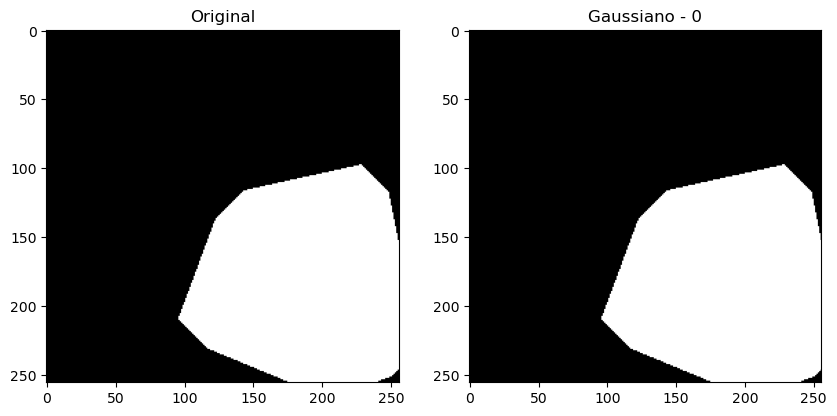

In [205]:
from skimage.filters import gaussian

spotGaussian0 = gaussian(spot, sigma=0, preserve_range=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(spot, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,2,2)
plt.imshow(spotGaussian0, cmap='gray', vmin=0, vmax=255)
plt.title("Gaussiano - 0")
plt.show()


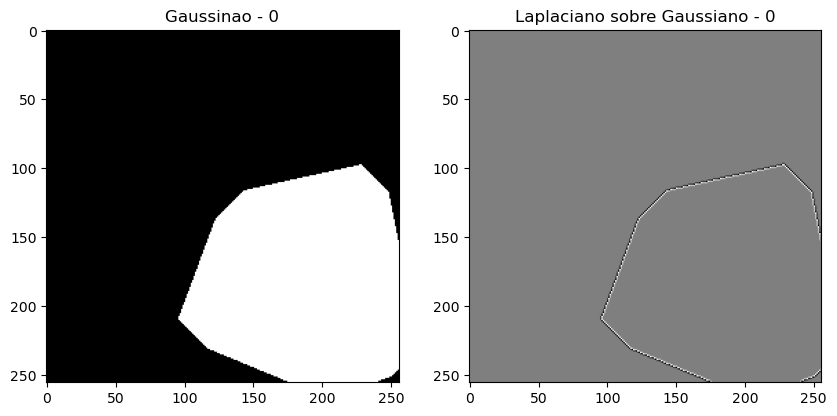

In [206]:
spotGaussian0Laplacian = laplace(spotGaussian0, ksize=3)
spotGaussian0Laplacian = exposure.rescale_intensity(spotGaussian0Laplacian, in_range=(spotGaussian0Laplacian.min(), spotGaussian0Laplacian.max()), out_range=(0, 255))
spotGaussian0Laplacian = spotGaussian0Laplacian.astype('uint8')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(spotGaussian0, cmap='gray', vmin=0, vmax=255)
plt.title("Gaussinao - 0")
plt.subplot(1,2,2)
plt.imshow(spotGaussian0Laplacian, cmap='gray', vmin=0, vmax=255)
plt.title("Laplaciano sobre Gaussiano - 0")
plt.show()


### ¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?

El filtro Laplaciano sobre Gaussiano debería reducir el ruido y evitar que pequeños detalles generen respuestas fuertes en el Laplaciano. Sin embargo, al aplicar una varianza de 0, este filtro no hace efecto y es como si el Gaussiano no se hubiera aplicado en primer lugar.

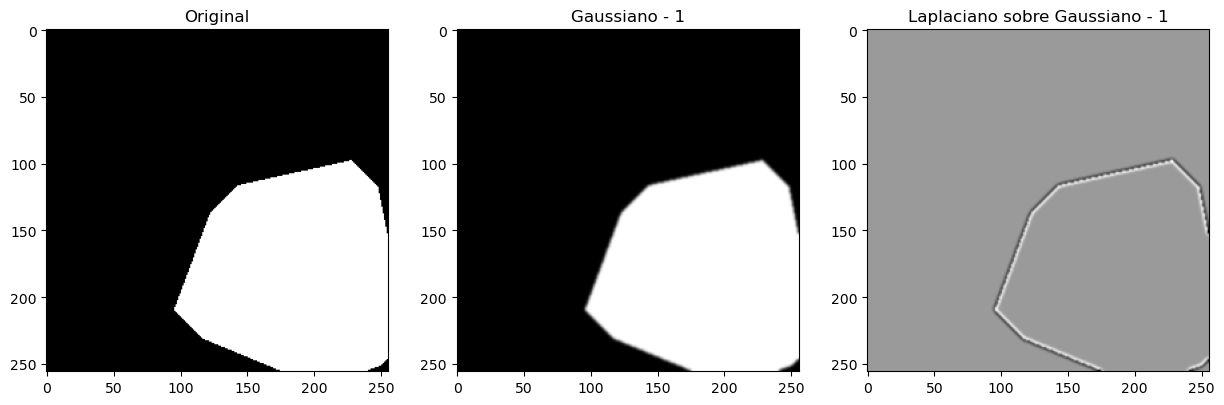

In [207]:
spotGaussian1 = gaussian(spot, sigma=1, preserve_range=True)
spotGaussian1Laplacian = laplace(spotGaussian1, ksize=3)
spotGaussian1Laplacian = exposure.rescale_intensity(spotGaussian1Laplacian, in_range=(spotGaussian1Laplacian.min(), spotGaussian1Laplacian.max()), out_range=(0, 255))
spotGaussian1Laplacian = spotGaussian1Laplacian.astype('uint8')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(spot, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(spotGaussian1, cmap='gray', vmin=0, vmax=255)
plt.title("Gaussiano - 1")
plt.subplot(1,3,3)
plt.imshow(spotGaussian1Laplacian, cmap='gray', vmin=0, vmax=255)
plt.title("Laplaciano sobre Gaussiano - 1")
plt.show()


### ¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?

Cuando la varianza del Gaussiano es superior a 0 (1 en este caso), el filtro Laplaciano sobre Gaussiano si reduce el ruido y evita que pequeños detalles irrelevantes generen respuestas fuertes en el Laplaciano. A diferencia del Laplaciano sin filtro previo (o Gaussiano con varianza 0) el LsG proporciona contornos más difuminados porque la imagen se suaviza antes de calcular la segunda derivada. Este resultado se debe a que el filtro Gaussiano es que elimina variaciones locales de alta frecuencia antes de calcular los cambios de intensidad en la imagen. Sin embargo, pareciera que en el resultado final los bordes siguen siendo un poco bruzcos.

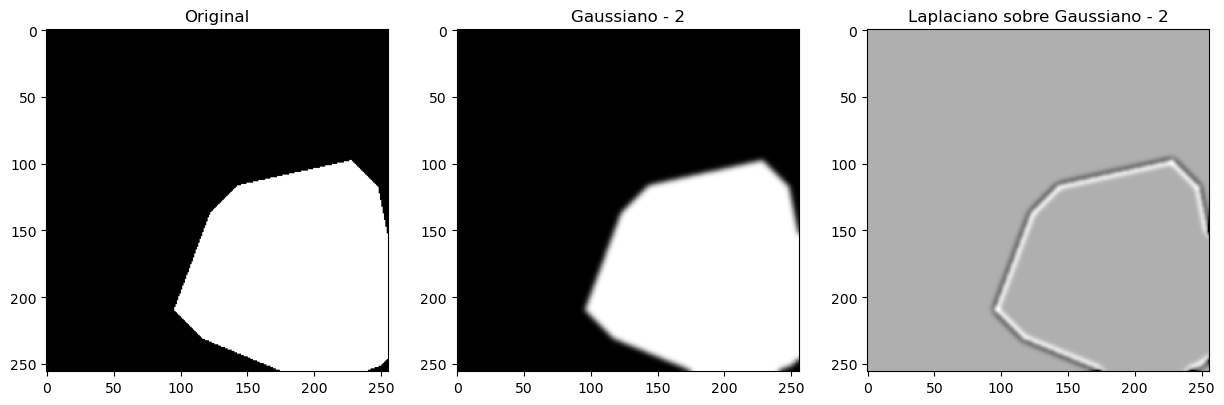

In [208]:
spotGaussian2 = gaussian(spot, sigma=2, preserve_range=True)
spotGaussian2Laplacian = laplace(spotGaussian2, ksize=3)
spotGaussian2Laplacian = exposure.rescale_intensity(spotGaussian2Laplacian, in_range=(spotGaussian2Laplacian.min(), spotGaussian2Laplacian.max()), out_range=(0, 255))
spotGaussian2Laplacian = spotGaussian2Laplacian.astype('uint8')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(spot, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(spotGaussian2, cmap='gray', vmin=0, vmax=255)
plt.title("Gaussiano - 2")
plt.subplot(1,3,3)
plt.imshow(spotGaussian2Laplacian, cmap='gray', vmin=0, vmax=255)
plt.title("Laplaciano sobre Gaussiano - 2")
plt.show()

### ¿Cómo es la respuesta de este LoG? ¿A qué se debe este resultado?

Cuando la varianza del Gaussiano es aún mayor (2 en este caso), la imagen se suaviza aún más y se eliminan más detalles finos. Se detectan solo los contornos principales, mientras que los bordes más pequeños y los detalles de alta frecuencia desaparecen. Aunque en este caso podemos ver que un poco más del suavizado del filtro Gaussiano se fe transferido al resultado final, a diferencia ddel caso anterior.

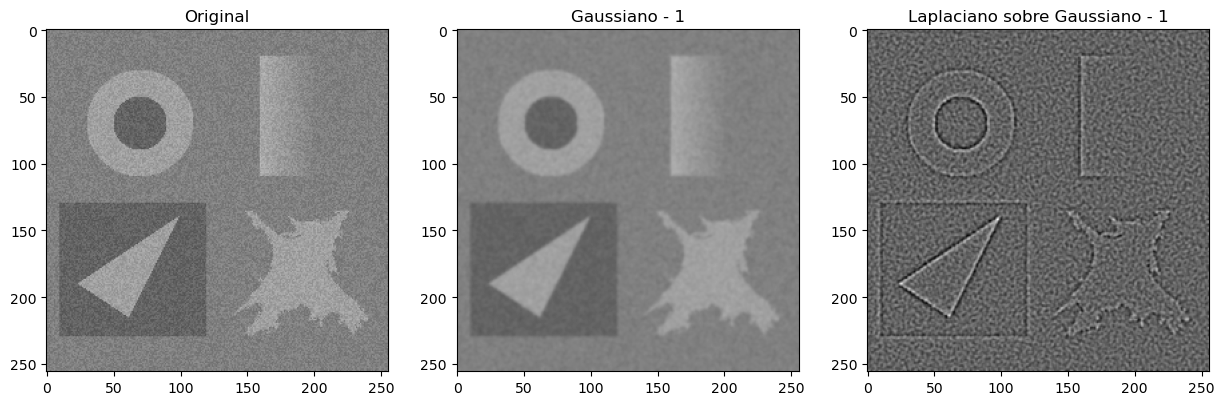

In [209]:
bruit = cv2.imread('BRUIT.png', cv2.IMREAD_GRAYSCALE)
bruit = bruit.astype('int16')

bruitGaussian1 = gaussian(bruit, sigma=1, preserve_range=True)
bruitGaussian1Laplacian = laplace(bruitGaussian1, ksize=3)
bruitGaussian1Laplacian = exposure.rescale_intensity(bruitGaussian1Laplacian, in_range=(bruitGaussian1Laplacian.min(), bruitGaussian1Laplacian.max()), out_range=(0, 255))
bruitGaussian1Laplacian = bruitGaussian1Laplacian.astype('uint8')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(bruit, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(bruitGaussian1, cmap='gray', vmin=0, vmax=255)
plt.title("Gaussiano - 1")
plt.subplot(1,3,3)
plt.imshow(bruitGaussian1Laplacian, cmap='gray', vmin=0, vmax=255)
plt.title("Laplaciano sobre Gaussiano - 1")
plt.show()

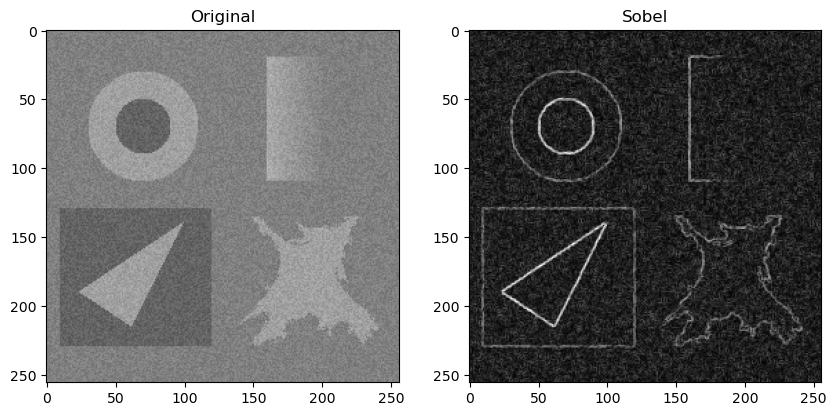

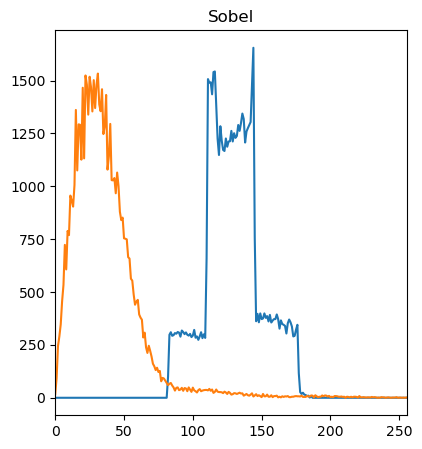

In [210]:
import numpy as np

sobel_x = sobel_h(bruit)
sobel_y = sobel_v(bruit)
bruitSobel = np.hypot(sobel_x, sobel_y)
bruitSobel = exposure.rescale_intensity(bruitSobel, in_range=(bruitSobel.min(), bruitSobel.max()), out_range=(0, 255))
bruitSobel = bruitSobel.astype('uint8')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(bruit, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,2,2)
plt.imshow(bruitSobel, cmap='gray', vmin=0, vmax=255)
plt.title("Sobel")
plt.show()

bruit = bruit.astype(np.uint8)
histBO = cv2.calcHist([bruit],[0],None,[256],[0,256])
histBS = cv2.calcHist([bruitSobel],[0],None,[256],[0,256])

plt.figure(figsize=(10,5))
plt.subplot(1,2,2)
plt.plot(histBO)  
plt.title("Original")
plt.xlim([0,256])
plt.subplot(1,2,2)
plt.plot(histBS)  
plt.title("Sobel")
plt.xlim([0,256])
plt.show()

### ¿En cuál de las dos imágenes es más fácil detectar los contornos. ¿Por qué ? ¿Cómo afecta el ruido la detección de los contornos en cada caso?

Ambos métodos son diferentes y el contraste es efectivo a la hora de resaltar los bordes de las figuras, pero en lo personal me gusta más la manera en la que el método Sobel delimita las figuras . Sobel resalta mejor los bordes al detectar cambios de intensidad en direcciones específicas (horizontal y vertical), en cuanto a su aspecto, es como una tiza sobre un tablero. Por otro lado, LoG puede generar contornos más definidos pero también amplificar el ruido. Esto ocurre porque LoG realza regiones con alta variación, incluyendo pequeñas fluctuaciones indeseadas, lo que puede generar falsos bordes. En cuanto a su aspecto, LsG es como si las figuras fueran una textura sobre un plano granulado y lo que las delimita es la sombra que generan como consecuencia de una iluminación exterior.

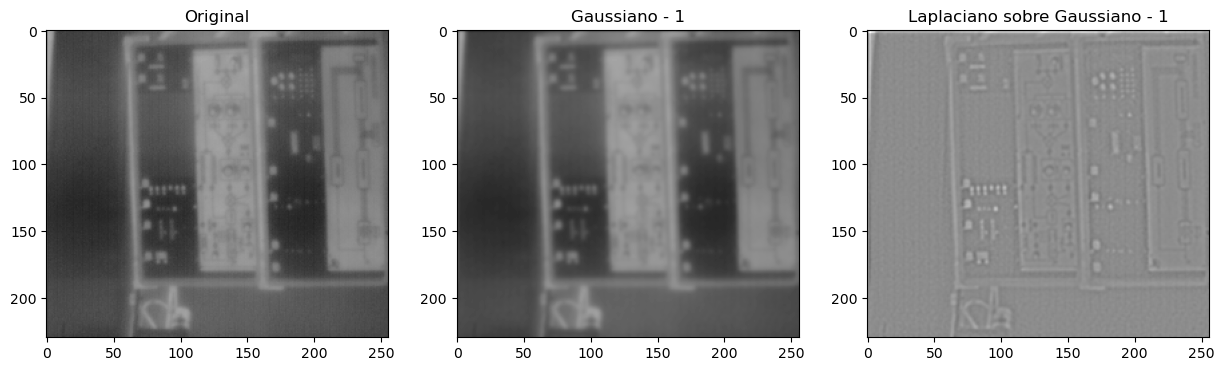

In [211]:
film = cv2.imread('FILM.png', cv2.IMREAD_GRAYSCALE)
film = film.astype('int16')

filmGaussian1 = gaussian(film, sigma=1, preserve_range=True)
filmGaussian1Laplacian = laplace(filmGaussian1, ksize=3)
filmGaussian1Laplacian = exposure.rescale_intensity(filmGaussian1Laplacian, in_range=(filmGaussian1Laplacian.min(), filmGaussian1Laplacian.max()), out_range=(0, 255))
filmGaussian1Laplacian = filmGaussian1Laplacian.astype('uint8')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(film, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(filmGaussian1, cmap='gray', vmin=0, vmax=255)
plt.title("Gaussiano - 1")
plt.subplot(1,3,3)
plt.imshow(filmGaussian1Laplacian, cmap='gray', vmin=0, vmax=255)
plt.title("Laplaciano sobre Gaussiano - 1")
plt.show()


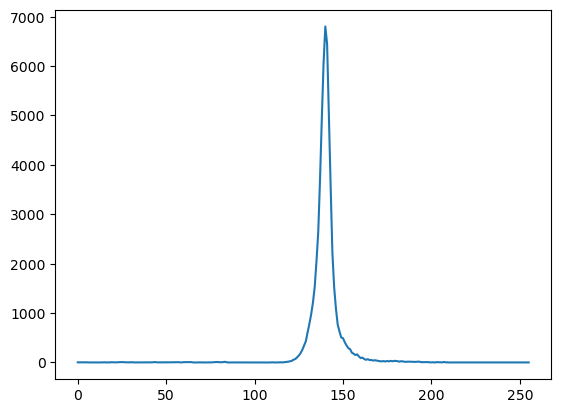

In [212]:
filmGaussian1Laplacian = filmGaussian1Laplacian.astype(np.uint8)
histFG1L = cv2.calcHist([filmGaussian1Laplacian],[0],None,[256],[0,256])
plt.plot(histFG1L)  
plt.show()

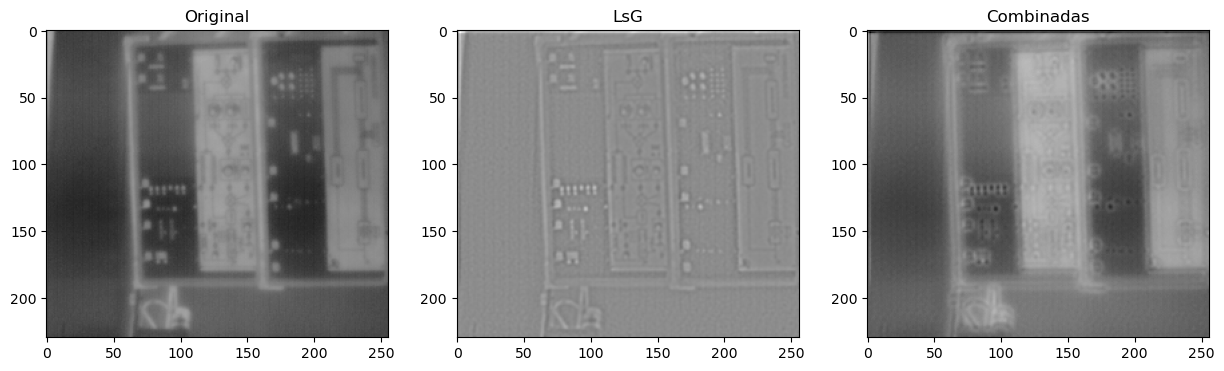

In [ ]:
filmCombined = 0.6 * film + (255 - filmGaussian1Laplacian)
filmCombined = np.clip(filmCombined, 0, 255).astype('uint8')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(film, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(filmGaussian1Laplacian, cmap='gray')
plt.title("LsG")
plt.subplot(1,3,3)
plt.imshow(filmCombined, cmap='gray')
plt.title("Combinadas")
plt.show()

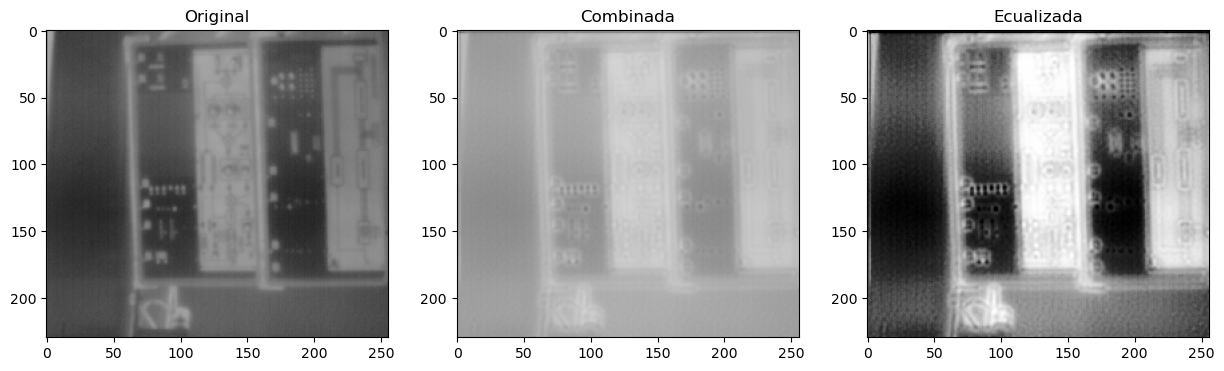

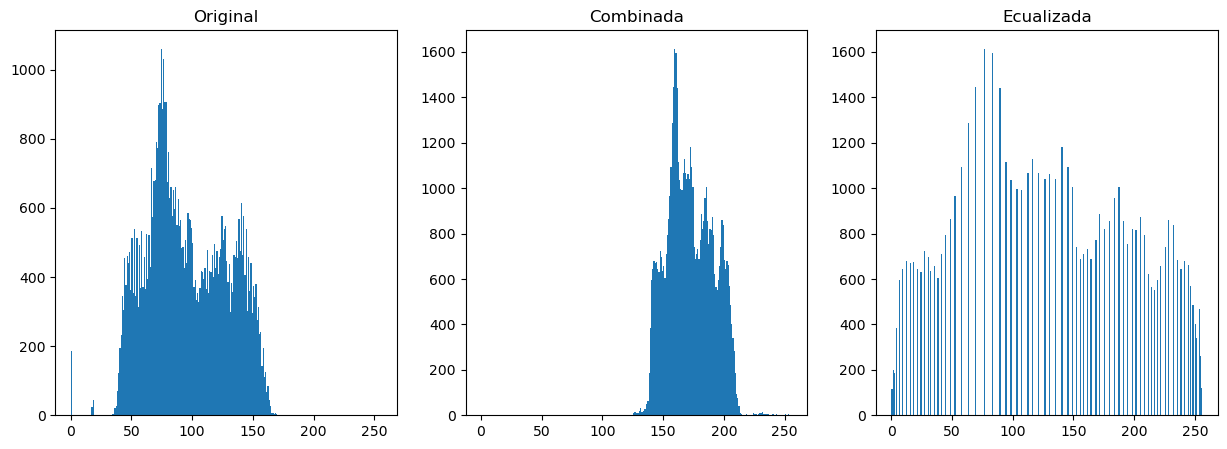

In [215]:
film = np.clip(film, 0, 255).astype(np.uint8)
film_equalized = cv2.equalizeHist(film)
film_combined_equalized = cv2.equalizeHist(filmCombined)


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(film, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(filmCombined, cmap='gray', vmin=0, vmax=255)
plt.title("Combinada")
plt.subplot(1,3,3)
plt.imshow(film_combined_equalized, cmap='gray', vmin=0, vmax=255)
plt.title("Ecualizada")
plt.show()

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(film.ravel(), bins=256, range=[0,256])
plt.title("Original")
plt.subplot(1,3,2)
plt.hist(filmCombined.ravel(), bins=256, range=[0,256])
plt.title("Combinada")
plt.subplot(1,3,3)
plt.hist(film_combined_equalized.ravel(), bins=256, range=[0,256])
plt.title("Ecualizada")
plt.show()


### Conclusión:

La imagen original presenta un contraste moderado, mientras que la combinada parece suavizar los detalles al incorporar el filtro LoG. La ecualización del histograma mejora el contraste, distribuyendo los niveles de gris de manera más uniforme y resaltando detalles que antes eran menos visibles. Los histogramas muestran cómo la ecualización expande la gama tonal. Para resaltar mejor los bordes.